# Apparent magnitude estimation

Scratchpad for experimenting with turning the `source`/`image`/`flux` tables produced by
`pw-aperture` into calibrated apparent magnitudes, ahead of implementing
`photometry_workflow.apparent_magnitude.api.estimate_apparent_magnitude`.

Approach used below (method 1 from `src/photometry_workflow/apparent_magnitude/CLAUDE.md`):
for each image, take the sources with a Gaia match (`gaia_matched`) as calibrators, compute a
single zero point from them, and apply it to every source's instrumental flux in that image.

Still to try, per the module's notes:
- weight calibrator contributions to the zero point (e.g. by flux scatter across apertures/images)
- iterative minimization of check-star magnitude variance instead of a plain median zero point
- selecting comparison stars from Gaia color/magnitude rather than using every matched source
- propagating flux/background uncertainty through to a magnitude error

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join

## Load the tables

Point `reduce_dir` at a folder written by `pw-aperture` (i.e. containing `sources.*`,
`images.*`, `flux.*`).

In [5]:
reduce_dir = Path("/home/adamarthurryan/Desktop/baron obs/pandora/pandorahatp11multibandseries_20260701_baron_gp/reduce")
#reduce_dir = Path("/home/adamarthurryan/Desktop/baron obs/mkr421/mrk421microvariabilityirg_20260708_baron_ip/reduce")
gaia_filter_key = "g_sdss_mag"

source_table = Table.read(next(reduce_dir.glob("sources.*")))
image_table = Table.read(next(reduce_dir.glob("images.*")))
flux_table = Table.read(next(reduce_dir.glob("flux.*")))

len(source_table), len(image_table), len(flux_table)

(100, 14, 1400)

## Pick an aperture

`flux_table["flux"]` and `flux_table["bkg"]` are vectors over the relative aperture radii
used by `pw-aperture` (`relative_apertures_radii` in `aperture_photometry/api.py`). Start with a
single fixed aperture index picked by eye; revisit with a proper curve-of-growth choice later.

In [6]:
aperture_index = 20

flux_ap_table = Table()
flux_ap_table["image_id"] = flux_table["image_id"]
flux_ap_table["source_id"] = flux_table["source_id"]
flux_ap_table["src_flux"] = flux_table["src_flux"][:, aperture_index]
flux_ap_table["bkg_flux"] = flux_table["bkg_flux"][:, aperture_index]
flux_ap_table["src_flux_error"] = flux_table["src_flux_error"][:, aperture_index]

In [7]:
flux_ap_table

image_id,source_id,src_flux,bkg_flux,src_flux_error
int64,int64,float64,float64,float64
0,0,1132159.2362962496,100474.72642720316,1197.7422174510727
0,1,902768.1968143019,97591.4598980103,967.0229933197577
0,2,831429.1737448865,97265.4499729098,928.7119321039224
0,3,603902.1633453105,97331.82553669042,799.783463634963
0,4,387635.27130260045,96762.59426196449,645.7380690156106
0,5,324186.82294626883,96702.99241248608,596.2742920241556
0,6,239093.6875854299,96208.52835937691,516.9249824586017
0,7,231335.76442809898,96156.9535607411,509.4673200374502
0,8,218291.08486829756,96175.87324551625,496.67966153798915


## Per-image zero point from Gaia-matched calibrators

In [8]:
calibrators = source_table[source_table["gaia_matched"]]["source_id", gaia_filter_key]

zero_points = []
for image_id in image_table["image_id"]:
    image_flux = flux_ap_table[flux_ap_table["image_id"] == image_id]
    calibrator_flux = join(image_flux, calibrators, keys="source_id")

    instrumental_mag = -2.5 * np.log10(calibrator_flux["src_flux"])
    zero_point = np.median(calibrator_flux[gaia_filter_key] - instrumental_mag)
    zero_points.append(zero_point)

image_table["zero_point"] = zero_points
image_table["image_id", "time", "zero_point"]

/home/adamarthurryan/micromamba/envs/photometry/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


image_id,time,zero_point
int64,float64,float64
0,2461223.961464271,24.789509884239322
1,2461223.9618620602,24.349973870275903
2,2461223.9622663655,24.3647716359714
3,2461223.9626872456,24.405441759495453
4,2461223.9631172568,24.404377010928048
5,2461223.963563287,24.383357462712706
6,2461223.964022743,24.459078216360894
7,2461223.9644639236,24.467310528967108
8,2461223.9649444097,24.637475862103273


## Apply the zero point to every source

In [9]:
flux_ap_table = join(flux_ap_table, image_table["image_id", "time", "zero_point"], keys="image_id")
instrumental_mag = -2.5 * np.log10(flux_ap_table["src_flux"])
flux_ap_table["magnitude"] = instrumental_mag + flux_ap_table["zero_point"]

## Light curve for a single source

Set `target_source_id` to the `source_id` of the star of interest (look it up in
`source_table` by `centroid_x`/`centroid_y` or the cross-matched Gaia columns).

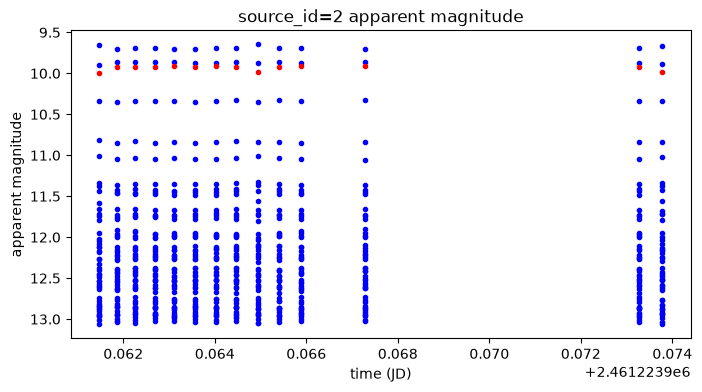

In [10]:
target_source_id = 2

plt.figure(figsize=(8, 4))

for i in range(0, 50):
    color="blue"
    if i==target_source_id:
        color="red"
    target_light_curve = flux_ap_table[flux_ap_table["source_id"] == i]
    target_light_curve.sort("time")
    plt.plot(target_light_curve["time"], target_light_curve["magnitude"], ".", color=color)

plt.gca().invert_yaxis()
plt.xlabel("time (JD)")
plt.ylabel("apparent magnitude")
plt.title(f"source_id={target_source_id} apparent magnitude")
plt.show()